In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 284807
Columns: 31


In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
print("Duplicates Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 1081
Duplicates After: 0


In [11]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


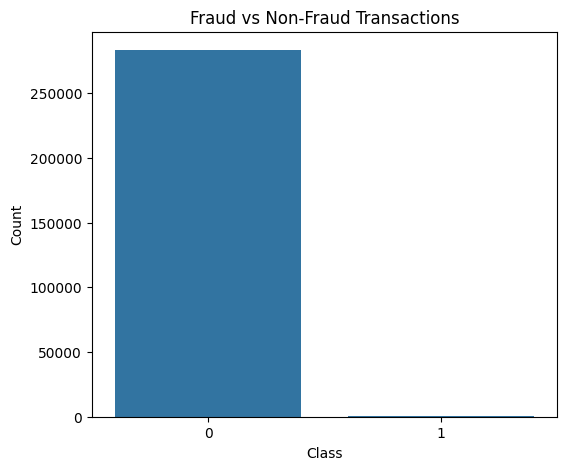

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig("../charts/class_distribution.png")
plt.show()


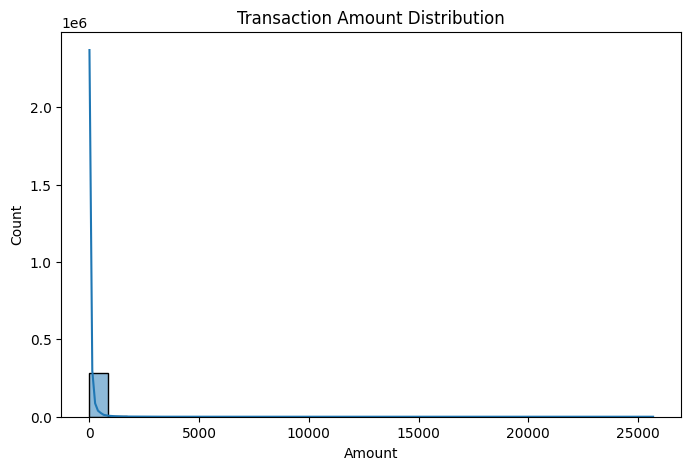

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=30, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")

plt.savefig("../charts/amount_distribution.png")
plt.show()

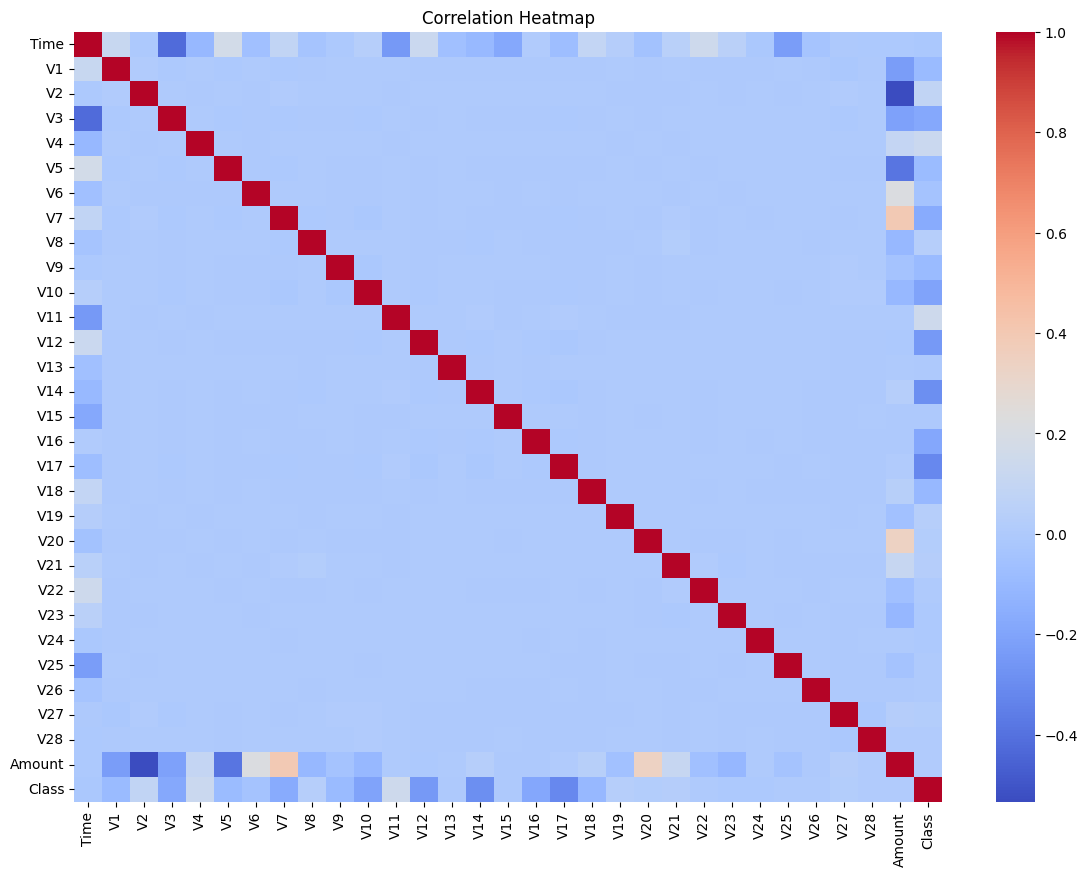

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../charts/correlation_heatmap.png")
plt.show()

In [15]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

print("Amount column scaled successfully!")

Amount column scaled successfully!


In [16]:
# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (283726, 30)
Target Shape: (283726,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (226980, 30)
Testing Data: (56746, 30)


In [18]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [19]:
log_pred = log_model.predict(X_test)

In [20]:
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, log_pred))

Accuracy : 0.9991717477883904
Precision: 0.875
Recall   : 0.5894736842105263
F1 Score : 0.7044025157232704
ROC-AUC  : 0.7946662343490012


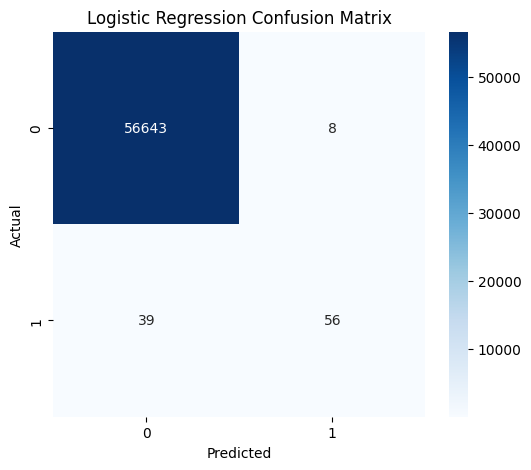

In [21]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../charts/logistic_confusion_matrix.png")
plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_pred))

Decision Tree Results
---------------------
Accuracy : 0.999048391076023
Precision: 0.7204301075268817
Recall   : 0.7052631578947368
F1 Score : 0.7127659574468085
ROC-AUC  : 0.8524021037395169


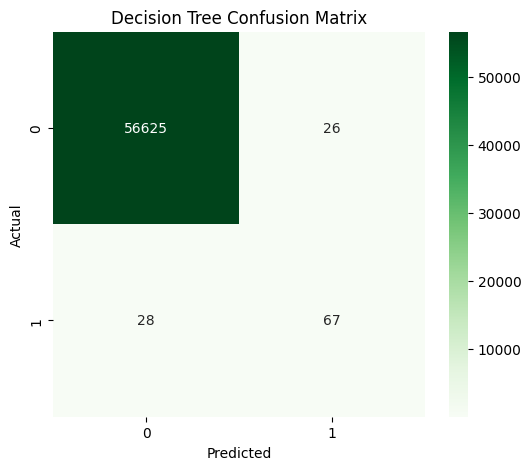

In [23]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../charts/decision_tree_confusion_matrix.png")
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy : 0.9995065731505305
Precision: 0.971830985915493
Recall   : 0.7263157894736842
F1 Score : 0.8313253012048193
ROC-AUC  : 0.8631402427977767


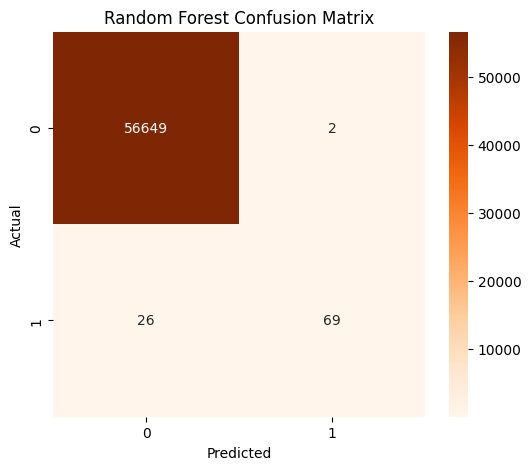

In [25]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../charts/random_forest_confusion_matrix.png")
plt.show()

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999172,0.875000,0.589474,0.704403
1,Decision Tree,0.999048,0.720430,0.705263,0.712766
2,Random Forest,0.999507,0.971831,0.726316,0.831325


In [27]:
comparison.to_csv("../outputs/model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best F1 Score:", grid_dt.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best F1 Score: 0.8229974228571987


In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50],
    "max_depth": [10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=2,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best F1 Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Best F1 Score: 0.8366201972118327


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,V17,0.156630
14,V14,0.135815
12,V12,0.130210
10,V10,0.087668
16,V16,0.072663
11,V11,0.050887
9,V9,0.033644
18,V18,0.031955
4,V4,0.025765
7,V7,0.024406


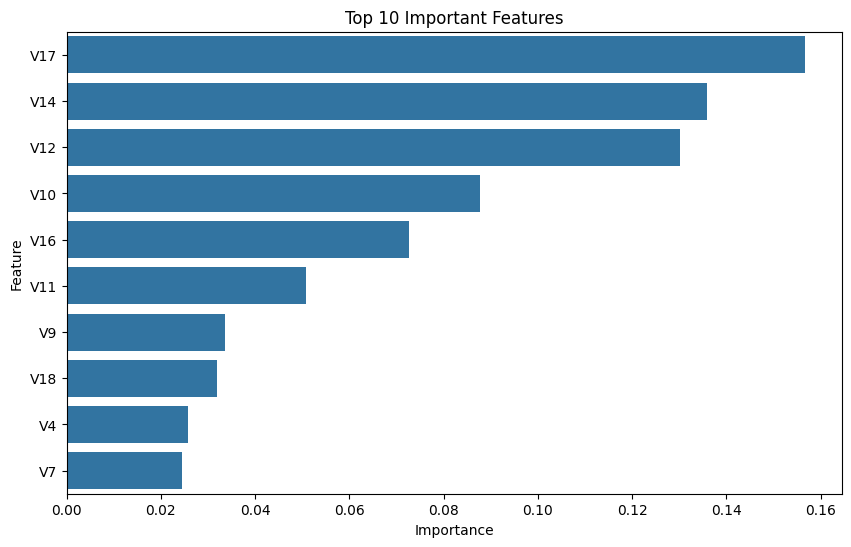

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig("../charts/feature_importance.png")

plt.show()

In [34]:
feature_importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("Feature Importance Saved Successfully!")

Feature Importance Saved Successfully!


In [35]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [36]:
import joblib

joblib.dump(rf_model, "../outputs/random_forest_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
